In [1]:
pip install scikit_posthocs

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp

In [4]:
# ---- Results for each MOEA --------
moead_df = pd.read_csv("MOEADDE_30runsFINAL.csv")
index_to_drop = moead_df[moead_df['dataset'] == 'glass.csv']
moead_df = moead_df.drop(index_to_drop.index, axis=0)
summary_moead = moead_df.groupby("dataset").agg(
    mean_accuracy=("test_accuracy", "mean"),
    mean_leaves=("num_leaves", "mean"),
    mean_hv=("hypervolume", "mean")
    ).reset_index()
summary_moead = summary_moead.round(4)

gde3_df = pd.read_csv("GDE3_30runsFINAL.csv")
index_to_drop2 = gde3_df[gde3_df['dataset'] == 'glass.csv']
gde3_df = gde3_df.drop(index_to_drop2.index, axis=0)
summary_gde3 = gde3_df.groupby("dataset").agg(
    mean_accuracy=("test_accuracy", "mean"),
    mean_leaves=("num_leaves", "mean"),
    mean_hv=("hypervolume", "mean")
    ).reset_index()
summary_gde3 = summary_gde3.round(4)

smsemoa_df = pd.read_csv("SMSEMOADE_30runsFINAL.csv")
index_to_drop3 = smsemoa_df[smsemoa_df['dataset'] == 'glass.csv']
smsemoa_df = smsemoa_df.drop(index_to_drop3.index, axis=0)
summary_smsemoa = smsemoa_df.groupby("dataset").agg(
    mean_accuracy=("test_accuracy", "mean"),
    mean_leaves=("num_leaves", "mean"),
    mean_hv=("hypervolume", "mean")
    ).reset_index()
summary_smsemoa = summary_smsemoa.round(4)

# results for jSO (runs for new datasets)
jso_df = pd.read_csv("jSO_30runs_metrics_5depth.csv")
index_to_drop4 = jso_df[jso_df['dataset'] == 'glass.csv']
jso_df = jso_df.drop(index_to_drop4.index, axis=0)
summary_jso_final = jso_df.groupby("dataset").agg(
    mean_accuracy=("test_accuracy", "mean"),
    mean_leaves=("num_leaves", "mean"),
    ).reset_index()

# Self-Adaptive DE (jSO) results
# copied values from Rivera-Lopez paper 2024
jso_accuracy = [0.8626, 0.9983, 0.8281, 0.8981, 0.8319, 0.9667, 0.8359, 0.9807, 0.9343, 0.9016]

jso_leaves = [5.43, 2.93, 24.00, 5.40, 12.23, 3.00, 2.67, 4.40, 4.37, 7.17]

datasets = ["australian.csv", "banknote.csv", "biodeg.csv", "cryotherapy.csv", "ecoli.csv", "iris.csv",
           "mammographic.csv", "occupancy.csv", "wine.csv", "zoo_cleaned.csv"]

summary_jso_first = pd.DataFrame({
    "dataset": datasets,
    "mean_accuracy": jso_accuracy,
    "mean_leaves": jso_leaves
})

summary_jso_final = summary_jso_final.round(4)
summary_jso = pd.concat([summary_jso_first, summary_jso_final], axis=0)
summary_jso = summary_jso.round(4).sort_values(by="dataset", ascending=True).reset_index(drop=True)


accuracy_matrix = np.column_stack([
    summary_gde3["mean_accuracy"],
    summary_moead["mean_accuracy"],
    summary_smsemoa["mean_accuracy"],
    summary_jso["mean_accuracy"]
])*100

leaves_matrix = np.column_stack([
    summary_gde3["mean_leaves"],
    summary_moead["mean_leaves"],
    summary_smsemoa["mean_leaves"],
    summary_jso["mean_leaves"]
]).round(2)

hv_matrix = np.column_stack([
    summary_gde3["mean_hv"],
    summary_moead["mean_hv"],
    summary_smsemoa["mean_hv"],
]).round(4)

In [6]:
# rows are datasets and columns are MOEAs + jSO
accuracy_matrix

array([[85.39, 85.31, 84.54, 86.26],
       [98.78, 99.1 , 99.44, 99.83],
       [83.49, 85.13, 83.52, 82.81],
       [90.19, 86.48, 82.41, 89.81],
       [91.85, 91.71, 88.29, 87.48],
       [82.11, 83.68, 82.21, 83.19],
       [65.83, 67.76, 65.52, 64.43],
       [80.22, 82.04, 79.35, 80.43],
       [93.29, 93.14, 93.33, 92.76],
       [87.89, 86.9 , 85.4 , 85.21],
       [95.67, 96.22, 94.44, 96.67],
       [70.27, 70.95, 70.67, 70.12],
       [79.33, 80.89, 77.78, 74.33],
       [83.49, 83.73, 83.37, 83.59],
       [98.24, 98.  , 98.26, 98.07],
       [86.92, 87.26, 87.18, 84.44],
       [93.73, 93.49, 91.9 , 91.43],
       [95.74, 95.35, 94.73, 94.03],
       [59.67, 60.75, 56.25, 55.04],
       [67.33, 68.18, 67.51, 66.43],
       [93.89, 94.54, 92.78, 93.43],
       [89.52, 89.37, 86.83, 90.16]])

In [7]:
# import accuracy data after applying post-hoc local search
postgde3 = pd.read_csv('results_posthocGDE3.csv')
postmoead = pd.read_csv('results_posthocMOEADDE.csv')
postsms = pd.read_csv('results_posthocSMSEMOADE.csv')

acc_gde3 = postgde3.groupby("Dataset").agg(mean_accuracy=("Test_Acc_After", "mean")).reset_index().round(4)
acc_moead = postmoead.groupby("Dataset").agg(mean_accuracy=("Test_Acc_After", "mean")).reset_index().round(4)
acc_sms = postsms.groupby("Dataset").agg(mean_accuracy=("Test_Acc_After", "mean")).reset_index().round(4)

In [8]:
# accuracy matrix with posthoc results
accuracy_matrix_post = np.column_stack([
    acc_gde3["mean_accuracy"],
    acc_moead["mean_accuracy"],
    acc_sms["mean_accuracy"],
    summary_jso["mean_accuracy"]
])*100

In [9]:
from scipy.stats import friedmanchisquare

# apply Friedman test
stat_acc, p_acc = friedmanchisquare(
    accuracy_matrix_post[:,0],
    accuracy_matrix_post[:,1],
    accuracy_matrix_post[:,2],
    accuracy_matrix_post[:,3],
)

stat_leaves, p_leaves = friedmanchisquare(
    leaves_matrix[:,0],
    leaves_matrix[:,1],
    leaves_matrix[:,2],
    leaves_matrix[:,3],
)

print("Friedman (accuracy) p =", p_acc, "stat =", stat_acc)
if p_acc < 0.05:
  print("Significant Differences in Accuracy")
print("Friedman (leaves)    p =", p_leaves, "stat = ", stat_leaves)
if p_leaves < 0.05:
  print("Significant Differences in Size")

Friedman (accuracy) p = 0.00046649145072893137 stat = 17.876146788990802
Significant Differences in Accuracy
Friedman (leaves)    p = 3.1728989697584426e-07 stat =  33.0307692307692
Significant Differences in Size


In [11]:
# rename columns for visualization
df_acc = pd.DataFrame(accuracy_matrix_post,
                      columns=["GDE3", "MOEA/D-DE", "SMS-EMOA-DE", "jSO"])
df_leaves = pd.DataFrame(leaves_matrix,
                         columns=["GDE3", "MOEA/D-DE", "SMS-EMOA-DE","jSO"])

# apply nemenyi post-hoc test
nemenyi_acc = sp.posthoc_nemenyi_friedman(df_acc)
nemenyi_leaves = sp.posthoc_nemenyi_friedman(df_leaves)

print("\nNemenyi p-values (accuracy):")
print(nemenyi_acc)

print("\nNemenyi p-values (leaves):")
print(nemenyi_leaves)


Nemenyi p-values (accuracy):
                 GDE3  MOEA/D-DE  SMS-EMOA-DE       jSO
GDE3         1.000000   0.817411     0.172094  0.026085
MOEA/D-DE    0.817411   1.000000     0.018418  0.001341
SMS-EMOA-DE  0.172094   0.018418     1.000000  0.872814
jSO          0.026085   0.001341     0.872814  1.000000

Nemenyi p-values (leaves):
                 GDE3  MOEA/D-DE  SMS-EMOA-DE       jSO
GDE3         1.000000   0.462091     0.026085  0.010626
MOEA/D-DE    0.462091   1.000000     0.000119  0.000031
SMS-EMOA-DE  0.026085   0.000119     1.000000  0.991344
jSO          0.010626   0.000031     0.991344  1.000000


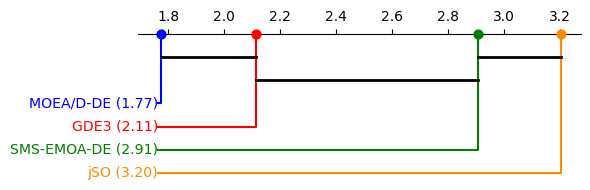

In [13]:
from scipy.stats import rankdata

# assign ranks
# the higher the accuracy the better the rank
ranks_acc = np.array([
    rankdata(-row, method="average") for row in accuracy_matrix_post
])

avg_ranks_acc = ranks_acc.mean(axis=0)
names = nemenyi_acc.columns.to_list()

avg_ranks_acc = pd.Series(
    avg_ranks_acc,
    index=names
)


sig_acc = pd.DataFrame(
    sp.sign_array(nemenyi_acc, alpha=0.05),
    index=nemenyi_acc.index,
    columns=nemenyi_acc.columns
)

# CD plot
from scikit_posthocs import critical_difference_diagram

plt.figure(figsize=(6, 2))

critical_difference_diagram(
    avg_ranks_acc,
    nemenyi_acc,
    label_props={"fontsize": 10.2},
    marker_props={"s": 40},
    label_fmt_left='{label} ({rank:.2f})',
    color_palette = {'GDE3': 'red', 'MOEA/D-DE': 'blue', 'SMS-EMOA-DE': 'green', 'jSO':'darkorange'},
    left_only=True
)

ax = plt.gca()
ax.xaxis.grid(False)

plt.tight_layout()
#plt.savefig("CDplot_acc.png", dpi=300) # increase dpi for high quality
plt.show()

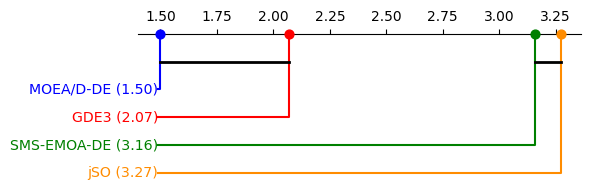

In [14]:
# menor número de hojas = mejor rank
ranks_leaves = np.array([
    rankdata(row, method="average") for row in leaves_matrix
])

avg_ranks_leaves = ranks_leaves.mean(axis=0)
names = nemenyi_leaves.columns.tolist()

avg_ranks_leaves = pd.Series(
    avg_ranks_leaves,
    index=names
)
sig_leaves = pd.DataFrame(
    sp.sign_array(nemenyi_leaves, alpha=0.05),
    index=nemenyi_leaves.index,
    columns=nemenyi_leaves.columns
)

plt.figure(figsize=(6, 2))

critical_difference_diagram(
    ranks = avg_ranks_leaves,
    sig_matrix = nemenyi_leaves,
    label_props={"fontsize": 10.2},
    marker_props={"s": 40},
    label_fmt_left='{label} ({rank:.2f})',
    color_palette = {'GDE3': 'red', 'MOEA/D-DE': 'blue', 'SMS-EMOA-DE': 'green', 'jSO':'darkorange'},
    left_only=True,
)

ax = plt.gca()
ax.xaxis.grid(False)

plt.tight_layout()
#plt.savefig("CDplot_leaves.png", dpi=400)
plt.show()